# Daten einlesen und ersten Überblick bekommen 

In [1]:
import pandas as pd
import os

base_path = "/datasets/multi-view-pig-posture-recognition"

# Laden der Trainingsdaten
train1_df = pd.read_csv(os.path.join(base_path, 'train1.csv'))
train2_df = pd.read_csv(os.path.join(base_path, 'train2.csv'))

train_df = pd.concat([train1_df, train2_df], ignore_index=True)

print(train_df.head())

<jemalloc>: Unsupported system page size


                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   
1  train_pen1_orb_cam1_20250108_085204_0001   
2  train_pen1_orb_cam1_20250108_085204_0002   
3  train_pen1_orb_cam1_20250108_085204_0003   
4  train_pen1_orb_cam1_20250108_085204_0004   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
1  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
2  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
3  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
4  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  
1  [1278.5,428.0,233.0,438.0]         4  
2   [732.0,137.5,342.0,198.0]         1  
3   [830.0,169.0,370.0,263.0]         0  
4   [611.5,314.8,381.5,386.6]         3  


In [2]:
# Zeigt alle Spaltennamen an
print("Spalten im Dataframe:", train_df.columns.tolist())

print("\nInhalt der ersten Zeile:")
print(train_df.iloc[0])

Spalten im Dataframe: ['row_id', 'image_id', 'width', 'height', 'bbox', 'class_id']

Inhalt der ersten Zeile:
row_id      train_pen1_orb_cam1_20250108_085204_0000
image_id           pen1_orb_cam1_20250108_085204.jpg
width                                           1920
height                                          1080
bbox                      [1031.5,368.0,349.0,435.0]
class_id                                           0
Name: 0, dtype: object


In [3]:
train1_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


In [4]:
train2_df.head()

,row_id,image_id,width,height,bbox,class_id
0,train_pen1_orb_cam1_20250108_085204_0000,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1031.5,368.0,349.0,435.0]",0
1,train_pen1_orb_cam1_20250108_085204_0001,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[1278.5,428.0,233.0,438.0]",4
2,train_pen1_orb_cam1_20250108_085204_0002,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[732.0,137.5,342.0,198.0]",1
3,train_pen1_orb_cam1_20250108_085204_0003,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[830.0,169.0,370.0,263.0]",0
4,train_pen1_orb_cam1_20250108_085204_0004,pen1_orb_cam1_20250108_085204.jpg,1920,1080,"[611.5,314.8,381.5,386.6]",3


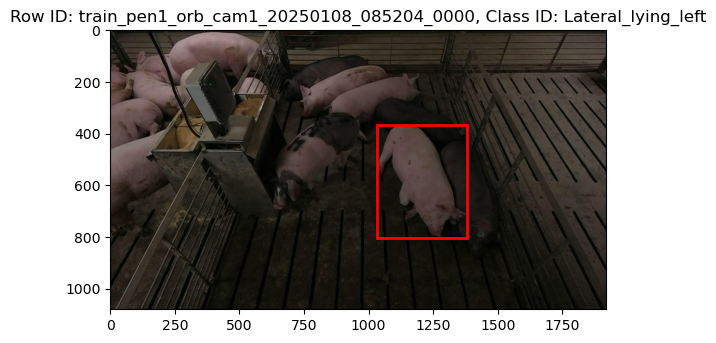

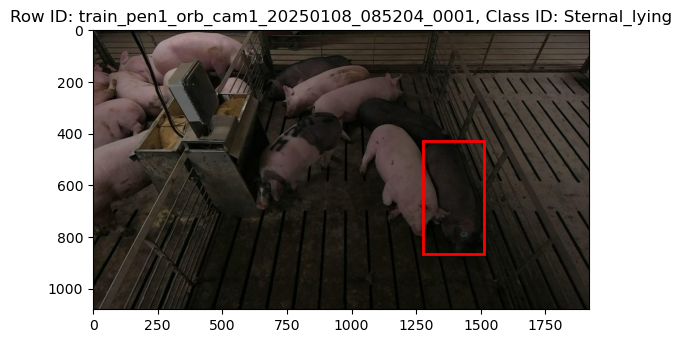

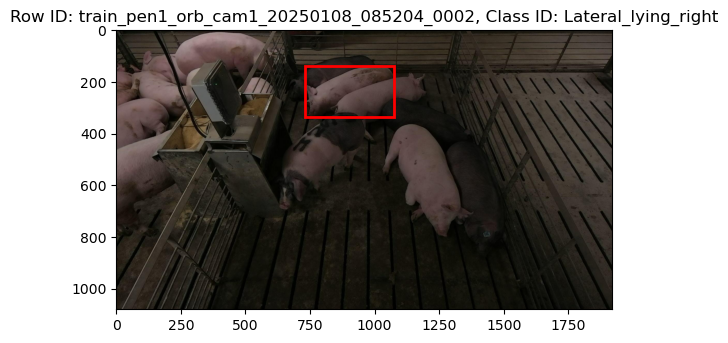

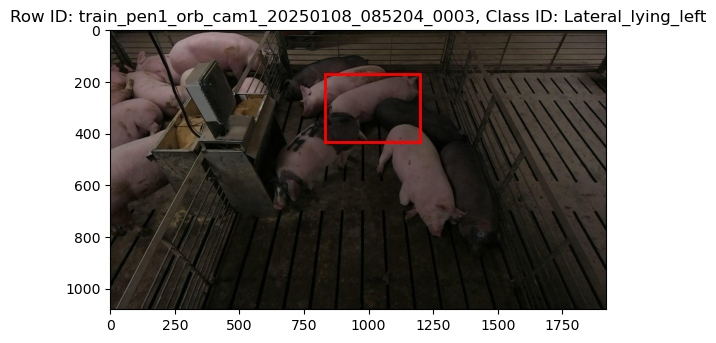

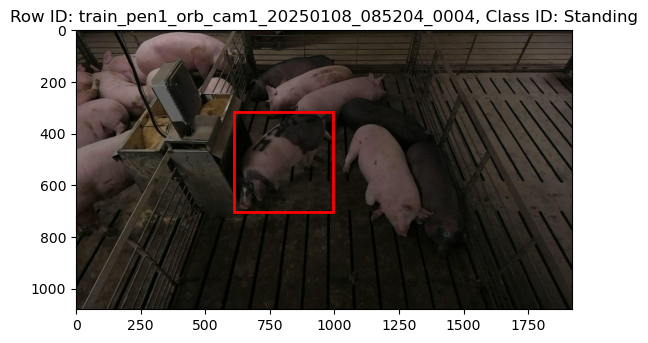

In [5]:
# data paths
train1_path = "/datasets/multi-view-pig-posture-recognition/train1_images"
train2_path = "/datasets/multi-view-pig-posture-recognition/train2_images"
test_path = "/datasets/multi-view-pig-posture-recognition/test_images"
# csv path with row_id, image_id, width, height, bbox, class_id
train1_csv = "/datasets/multi-view-pig-posture-recognition/train1.csv"
train2_csv = "/datasets/multi-view-pig-posture-recognition/train2.csv"
test_csv = "/datasets/multi-view-pig-posture-recognition/test.csv"
# pig posture classes
pig_posture_classes = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying"
}

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
train1 = pd.read_csv(train1_csv)
train2 = pd.read_csv(train2_csv)
test = pd.read_csv(test_csv)
#show the first 5 rows of train1 paired with their images and their bboxes drawn on the images
for i in range(5):
    row = train1.iloc[i]
    image_id = row["image_id"]
    image_path = f"{train1_path}/{image_id}"
    image = Image.open(image_path)
    plt.imshow(image)
    plt.title(f"Row ID: {row['row_id']}, Class ID: {pig_posture_classes[row['class_id']]}")
    # draw the bbox on the image
    bbox = eval(row["bbox"])
    x, y, w, h = bbox
    plt.gca().add_patch(plt.Rectangle((x, y), w, h, fill=False, edgecolor='red', linewidth=2))
    plt.show()

# EDA vom Projekt

In [12]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

BASE_PATH = "/datasets/multi-view-pig-posture-recognition"

# Beide CSVs laden
df1 = pd.read_csv(os.path.join(BASE_PATH, "train1.csv"))
df2 = pd.read_csv(os.path.join(BASE_PATH, "train2.csv"))

# Pfade zu den jeweiligen Ordnern ergänzen
df1['full_path'] = df1['image_id'].apply(lambda x: os.path.join(BASE_PATH, "train1_images", x))
df2['full_path'] = df2['image_id'].apply(lambda x: os.path.join(BASE_PATH, "train2_images", x))

# Zusammenführen zu einem großen DataFrame
df = pd.concat([df1, df2], ignore_index=True)

print(f"Gesamtanzahl Datensätze: {len(df)}")
print(f"Bilder in Set 1: {len(df1)} | Bilder in Set 2: {len(df2)}")

Gesamtanzahl Datensätze: 46384
Bilder in Set 1: 22934 | Bilder in Set 2: 23450


In [13]:
with open(os.path.join(BASE_PATH, "pig_posture_classes.txt"), "r") as f:
    print("Klassen-Definitionen:")
    print(f.read())

Klassen-Definitionen:
Lateral_lying_left
Lateral_lying_right
Sitting
Standing
Sternal_lying



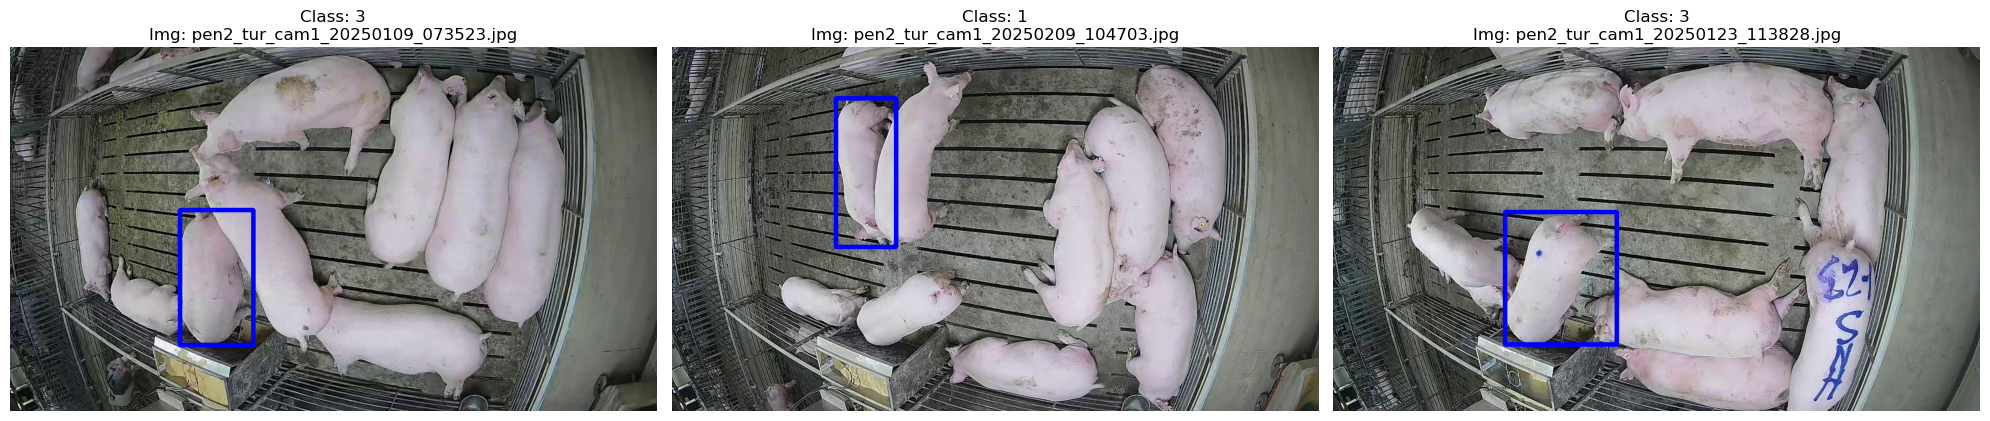

In [19]:
import ast
import matplotlib.pyplot as plt
import cv2

def plot_multi_view_samples_final_red(df, n=3):
    sample = df.sample(n)
    fig, axes = plt.subplots(1, n, figsize=(20, 10))
    
    # Falls nur 1 Bild angefragt wird, axes als Liste behandeln
    if n == 1: axes = [axes]

    for i, (idx, row) in enumerate(sample.iterrows()):
        # Bild laden (Pfad wurde in Schritt 1 erstellt)
        img = cv2.imread(row['full_path'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # Bbox konvertieren: aus "[x, y, w, h]" wird [x, y, w, h]
        bbox = row['bbox']
        if isinstance(bbox, str):
            bbox = ast.literal_eval(bbox)
        
        x, y, w, h = bbox
        
        # Zeichnen: Startpunkt (x,y) und Endpunkt (x+w, y+h)
        cv2.rectangle(img, (int(x), int(y)), 
                      (int(x + w), int(y + h)), (0, 0, 255), 8)
        
        axes[i].imshow(img)
        axes[i].set_title(f"Class: {row['class_id']}\nImg: {row['image_id']}")
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()

# Funktion aufrufen
plot_multi_view_samples_final_red(df, n=3)

/tmp/ipykernel_1130/2300978649.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='class_id', y='bbox_area', ax=ax[1], palette='viridis')


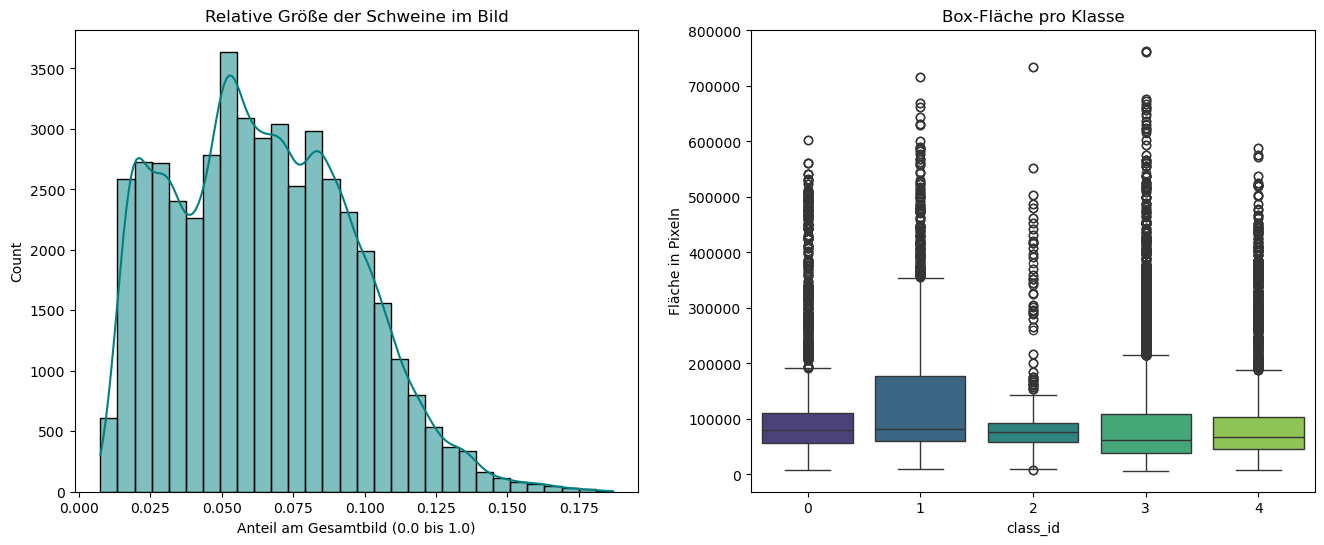

Durchschnittliche Box-Fläche: 94852 Pixel


In [20]:
# Hilfsspalten für die Analyse berechnen
def get_bbox_area(bbox):
    if isinstance(bbox, str):
        bbox = ast.literal_eval(bbox)
    return bbox[2] * bbox[3] # width * height

df['bbox_area'] = df['bbox'].apply(get_bbox_area)
df['img_area'] = df['width'] * df['height']
df['relative_size'] = df['bbox_area'] / df['img_area']

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# 1. Verteilung der relativen Größe (Wie viel % vom Bild nimmt das Schwein ein?)
sns.histplot(df['relative_size'], bins=30, kde=True, ax=ax[0], color='teal')
ax[0].set_title('Relative Größe der Schweine im Bild')
ax[0].set_xlabel('Anteil am Gesamtbild (0.0 bis 1.0)')

# 2. Box-Größe vs. Klasse (Sind liegende Schweine "größer" als stehende?)
sns.boxplot(data=df, x='class_id', y='bbox_area', ax=ax[1], palette='viridis')
ax[1].set_title('Box-Fläche pro Klasse')
ax[1].set_ylabel('Fläche in Pixeln')

plt.show()

print(f"Durchschnittliche Box-Fläche: {df['bbox_area'].mean():.0f} Pixel")

# Zusammenfassung der EDA-Ergebnisse

#### Relative Größe: Die Schweine belegen meist nur 2,5 % bis 10 % des Bildes. Der hohe Hintergrundanteil macht Ausschneiden der Boxen für das Modell-Training sinnvoll.Klassenunterschiede: Klasse 1 hat tendenziell die größten Bounding Boxes (vermutlich liegende Position), während die anderen Klassen kompakter sind.Bildqualität: Mit durchschnittlich ~95.000 Pixeln pro Box ist die Auflösung hoch genug für gängige Netze wie ResNet oder EfficientNet.Ausreißer: Die vielen Punkte in der Boxplot-Grafik zeigen, dass Tiere in unterschiedlichen Distanzen zur Kamera stehen, was das Modell robust gegenüber Skalierung machen muss.